<a href="https://colab.research.google.com/github/ranafikriyeak/MSc-Research/blob/main/case_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install uv
!pip install optuna
!uv pip install --system -r /content/drive/MyDrive/code/requirements-gpu.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 19.5 MB/s eta 0:00:00
Using Python 3.13.15 environment at: /usr
  × No solution found when resolving dependencies:
  ╰─▶ Because ml-dtypes==0.5.4 depends on numpy>=2.1.0 and you require
      ml-dtypes==0.5.4, we can conclude that you require numpy>=2.1.0.
      And because you require numpy>=2.0,<2.1, we can conclude that your
      requirements are unsatisfiable.


In [3]:
!pip install --upgrade jax jaxlib equinox diffrax optax optimistix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.0/403.0 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.8.2
    Uninstalling jaxlib-0.8.2:
      Successfully uninstalled jaxlib-0.8.2
  Attempting uninstall: jax
    Found existing installation: jax 0.8.2
    Uninstalling jax-0.8.2:
      Successfully uninstalled jax-0.8.2
  Attempting uninstall: optax
    Found existing installation: optax 0.2.4
    Uninstalling optax-0.2.4:
      Successfully uninstalled optax-0.2.4
  Attempting uninstall: equinox
    Found existing installation: equinox 0.13.2
   

In [5]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import optuna
import optimistix as optx
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, ODETerm, Kvaerno5, Tsit5, SaveAt, PIDController
import time
import numpy as np

import sys
repo_root = "/content/constrained-nodes"
sys.path.insert(0, repo_root)
repo_root = '/content/drive/MyDrive/code'
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
from batch_reactor import batch

ERROR:jax._src.xla_bridge:Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/jax/_src/xla_bridge.py", line 495, in discover_pjrt_plugins
    plugin_module.initialize()
    ~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/usr/local/lib/python3.13/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 370, in initialize
    _check_cuda_versions(raise_on_first_error = True)
    ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/jax_plugins/xla_cuda12/__init__.py", line 274, in _check_cuda_versions
    for d in range(cuda_versions.cuda_device_count())
                   ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:135: operation cuInit(0) failed: Unknown CUDA error 303; cuGetErrorName failed. This probably means that JAX was unable to load the CUDA libraries.


Generating datasets for all 4 conditions...
  0noise_sameIC: noise=0%, IC spread=0%
  2noise_sameIC: noise=2%, IC spread=0%
  2noise_diffIC: noise=2%, IC spread=40%
  0noise_diffIC: noise=0%, IC spread=40%

CONDITION: 0noise_sameIC  (noise=0%, IC spread=0%)

--- Training: 0noise_sameIC / Baseline ---
  [0noise_sameIC / Baseline] step     1  train 4.6718e+00  val 2.7774e+00  best 2.7774e+00 (@1)
  [0noise_sameIC / Baseline] step   200  train 3.2552e-04  val 3.3868e-04  best 3.3868e-04 (@200)
  [0noise_sameIC / Baseline] step   400  train 8.6672e-05  val 8.5223e-05  best 8.5223e-05 (@400)
  [0noise_sameIC / Baseline] step   600  train 7.9904e-05  val 4.7295e-05  best 2.3465e-05 (@500)
  [0noise_sameIC / Baseline] step   800  train 2.5963e-05  val 2.3896e-05  best 6.7056e-06 (@700)
  [0noise_sameIC / Baseline] step  1000  train 9.1345e-06  val 3.6425e-06  best 3.6425e-06 (@1000)
  [0noise_sameIC / Baseline] step  1200  train 1.1386e-04  val 7.6633e-05  best 3.0844e-06 (@1150)
  [0noise_sa

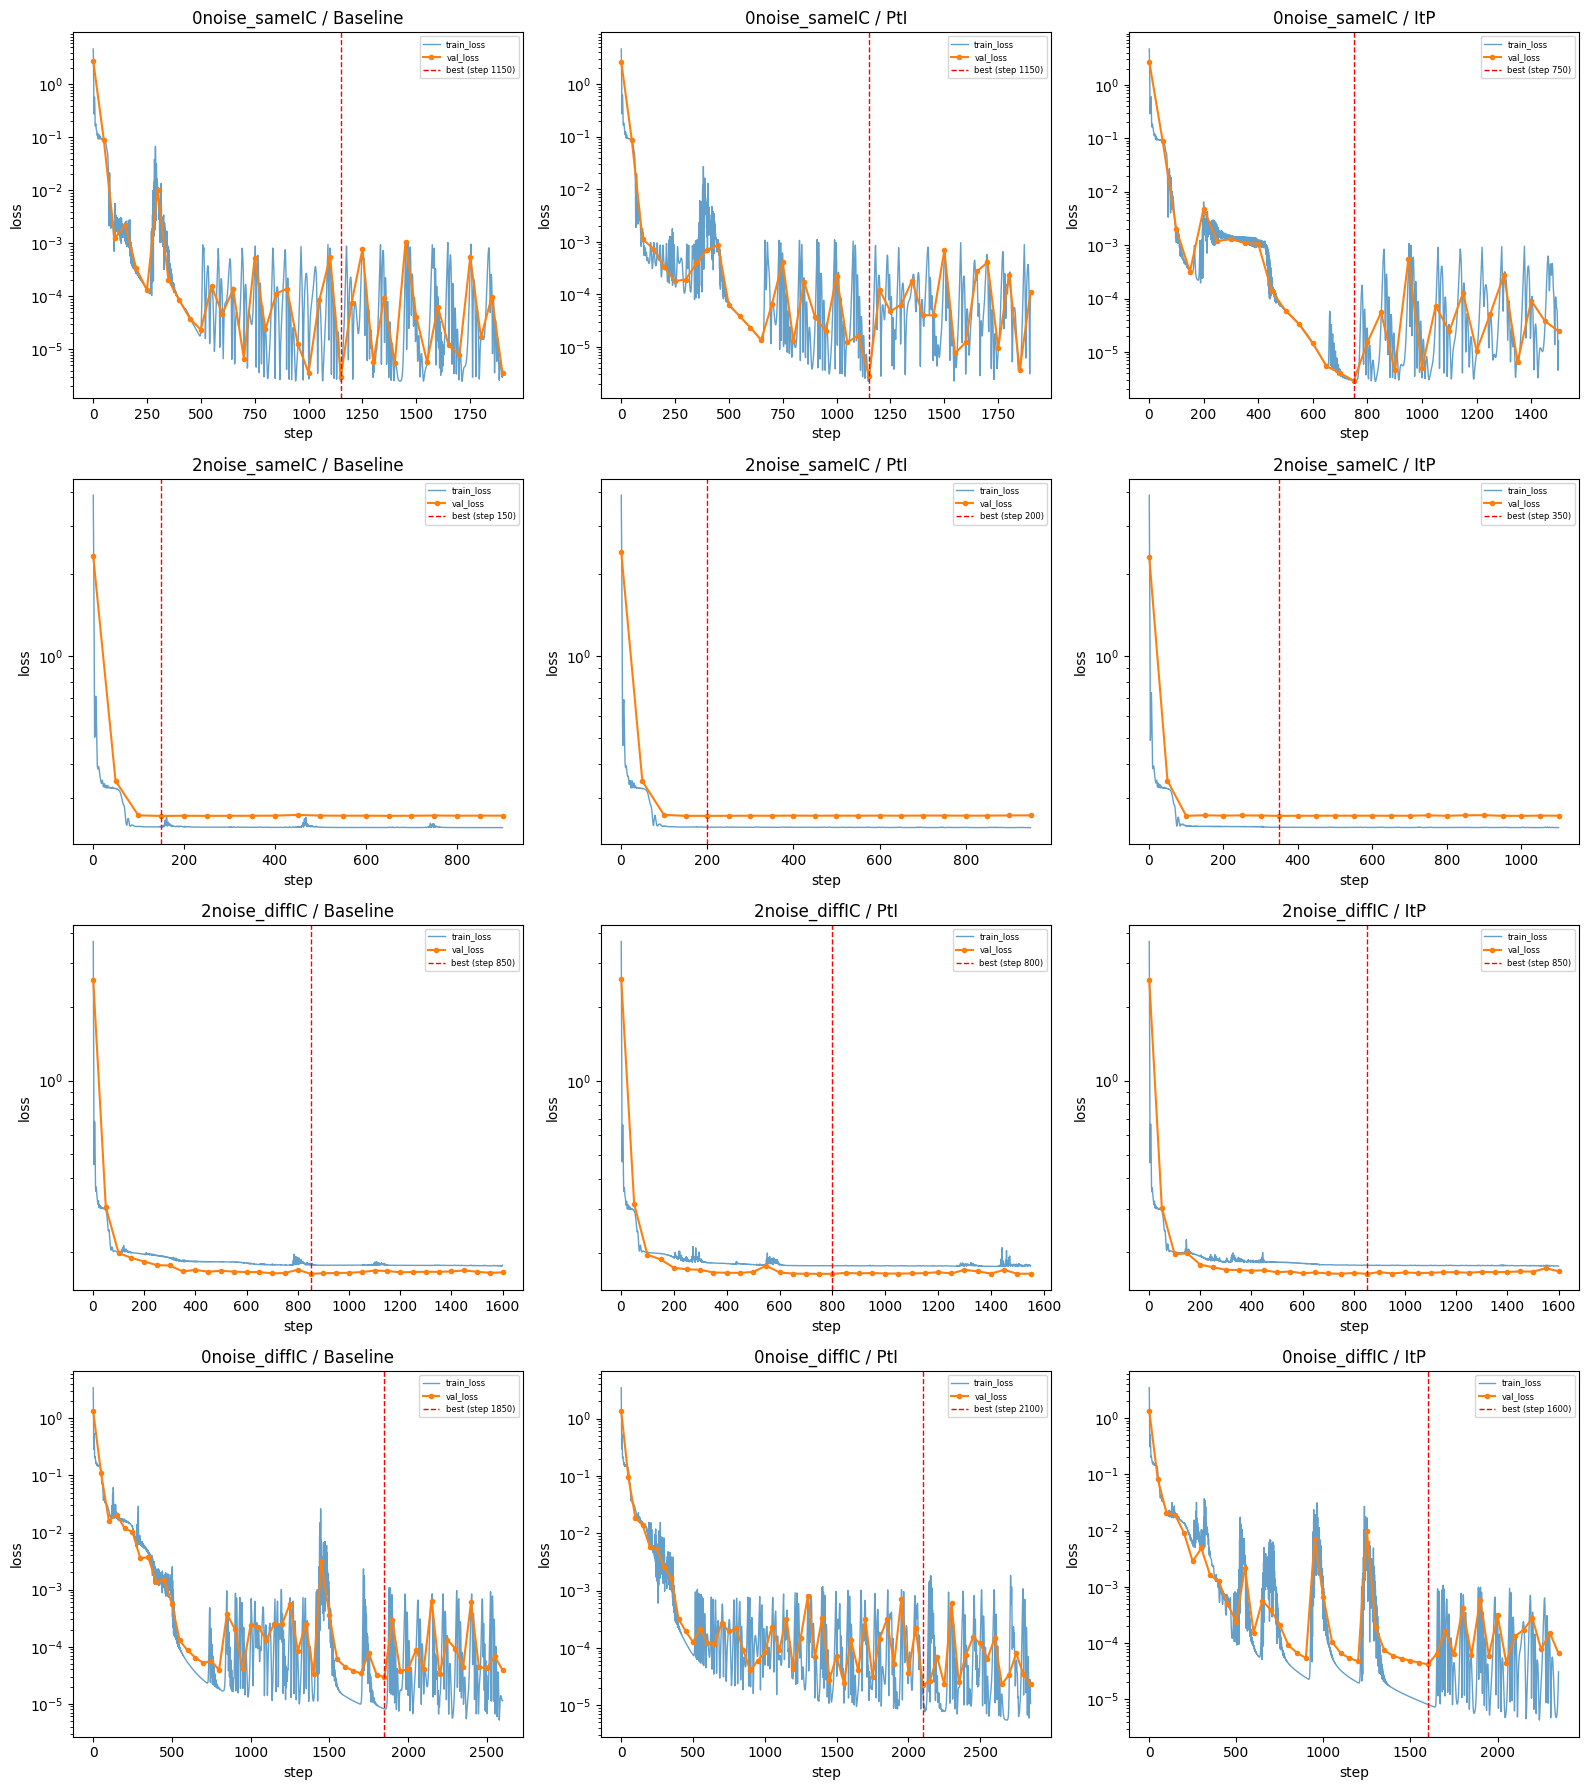

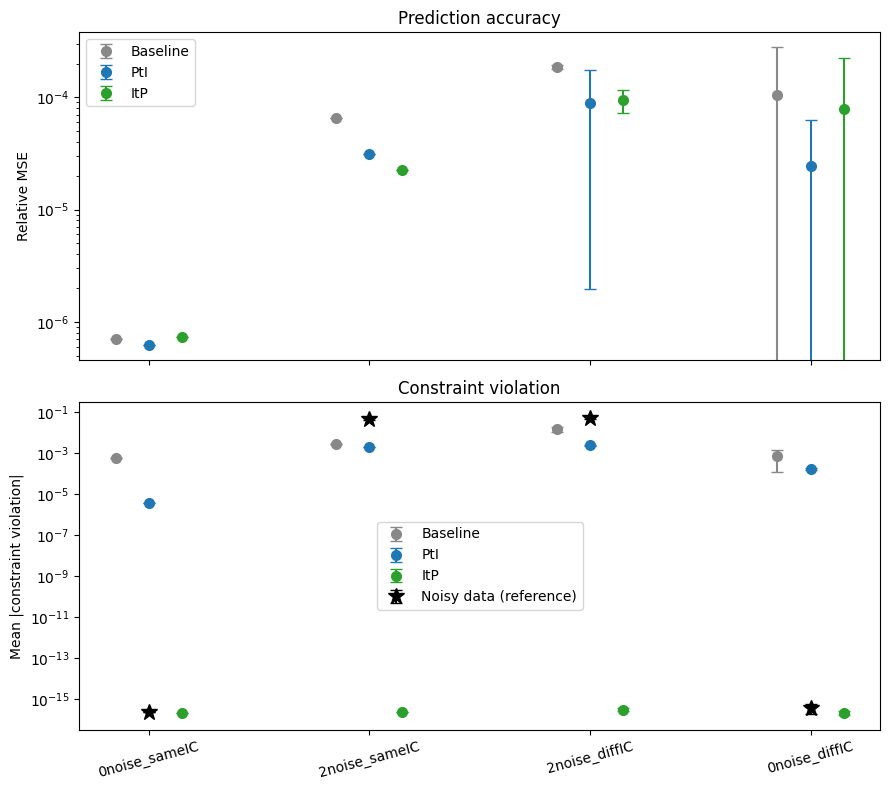

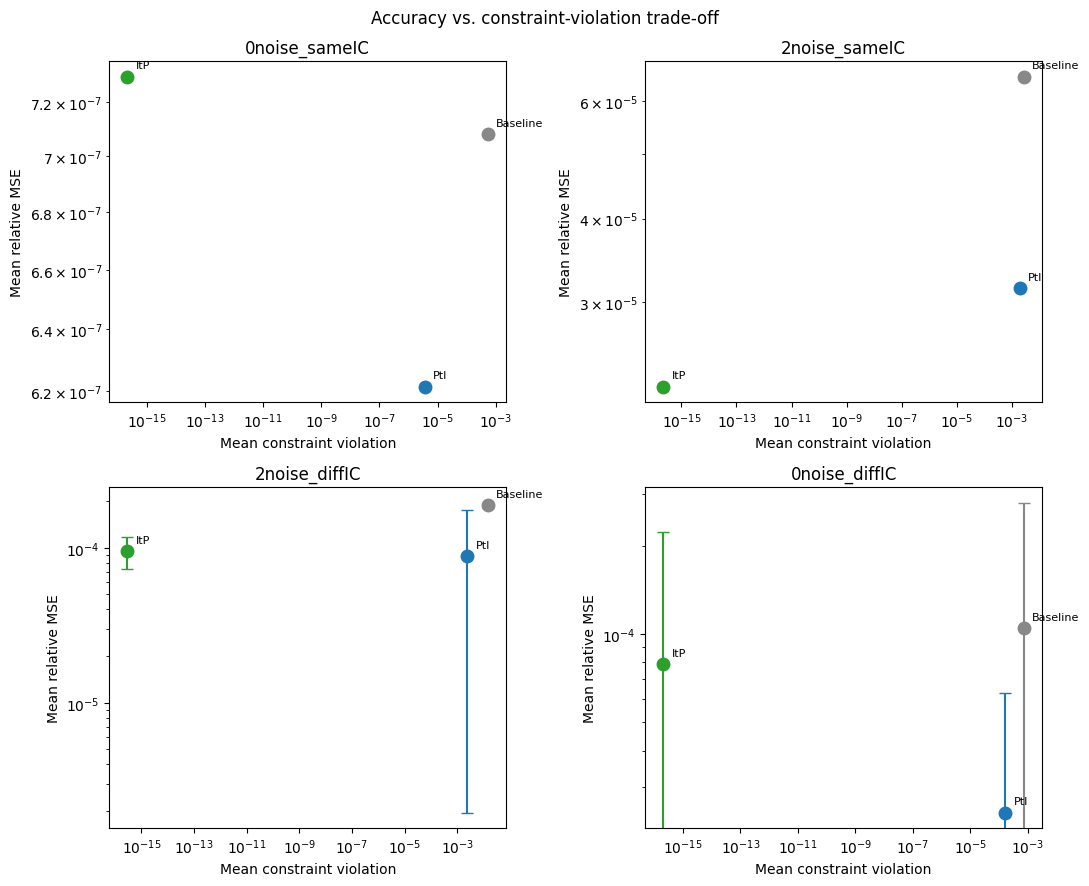

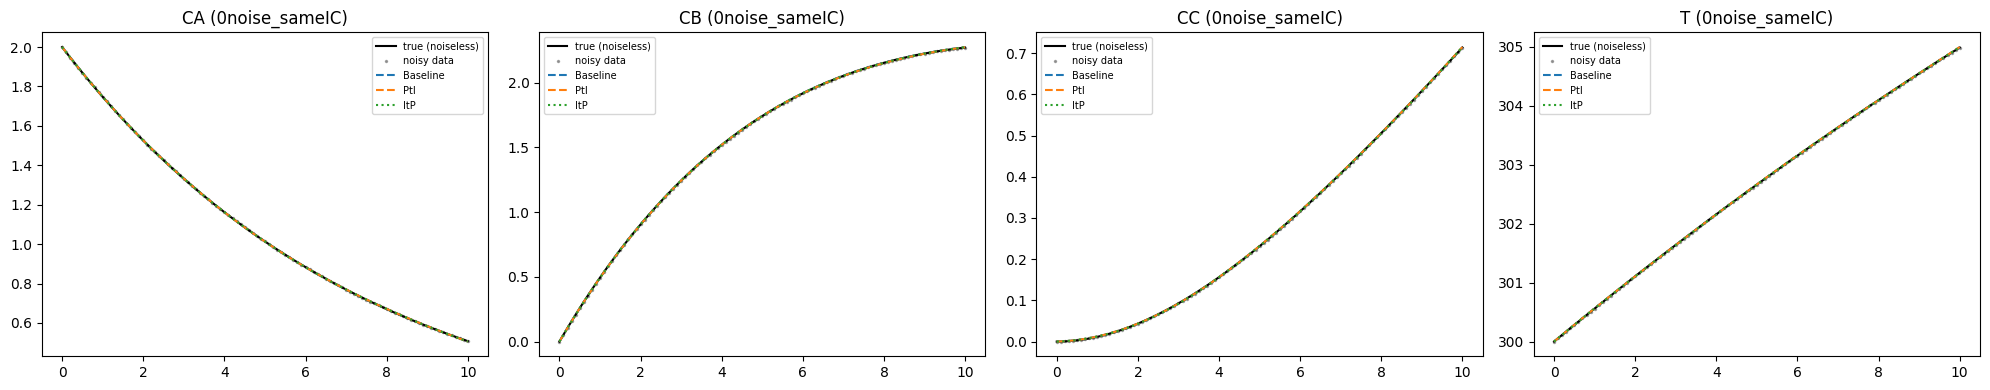

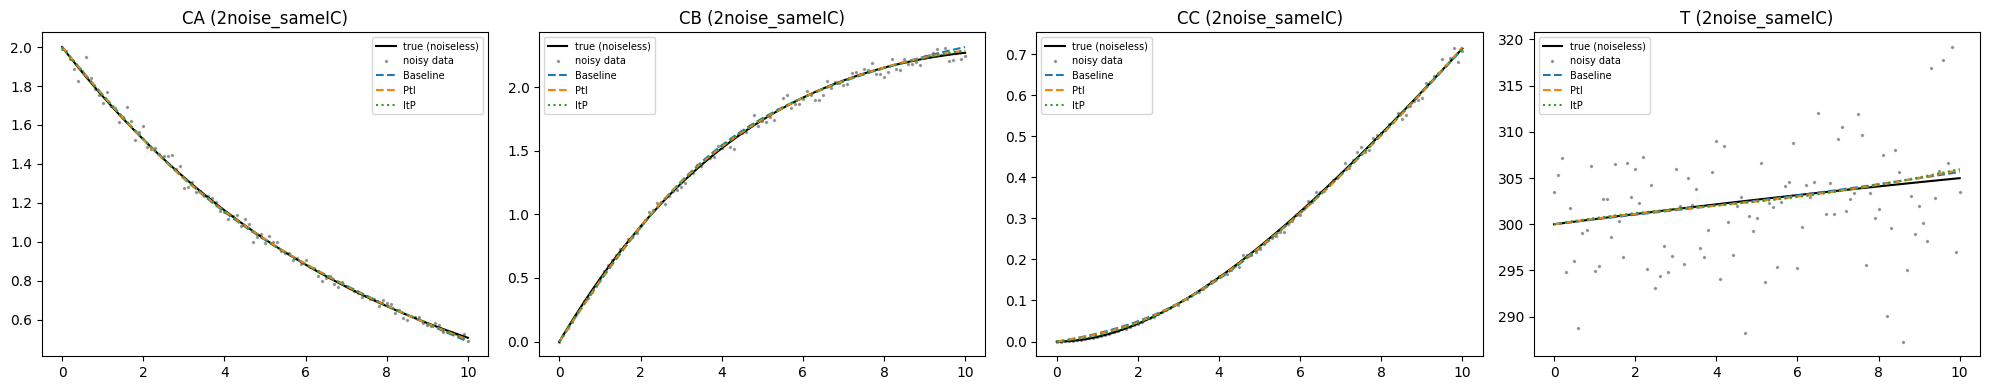

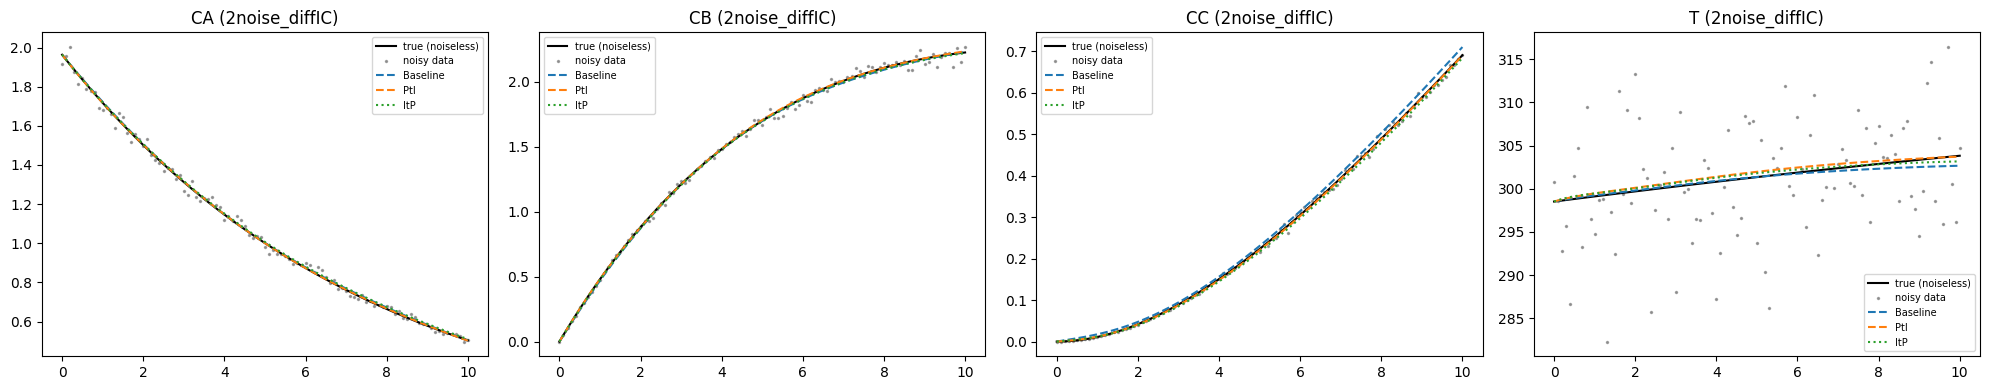

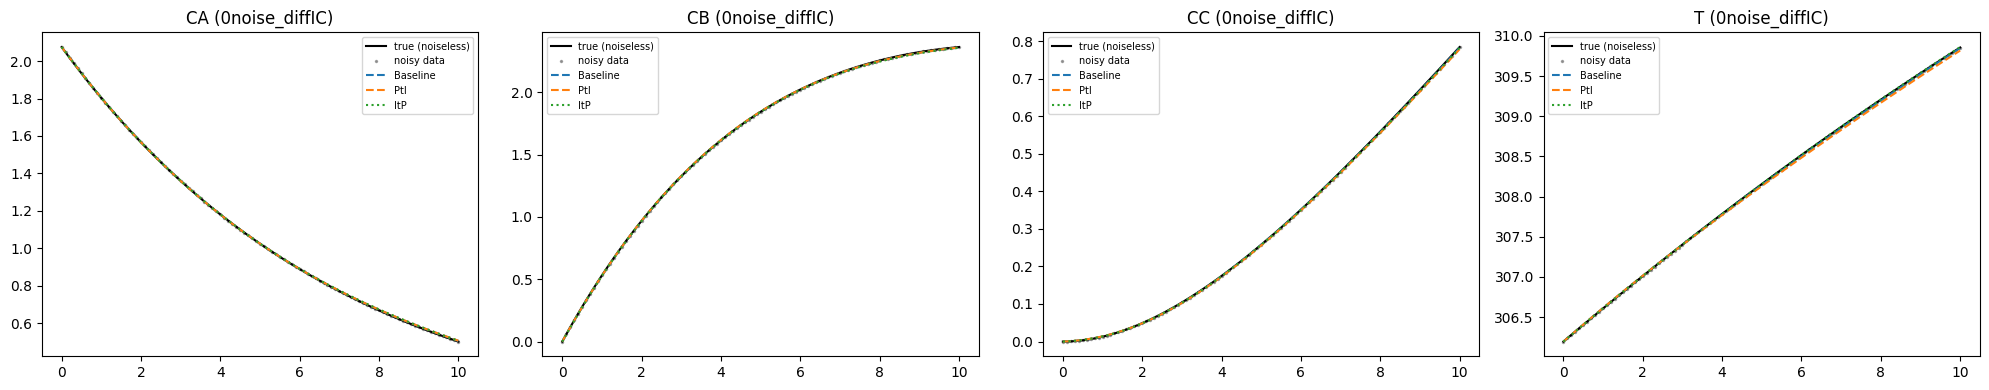


Done. All outputs saved to /mnt/user-data/outputs/
  - model_comparison_12configs.csv
  - noisy_data_constraint_violation.csv
  - loss_curves_12models.png          (train/val curves -> overfitting check)
  - summary_accuracy_violation.png    (dot-and-whisker summary, incl. noisy-data reference)
  - pareto_accuracy_vs_violation.png  (accuracy vs. constraint-violation trade-off)
  - trajectory_<condition>.png        (x4)


In [6]:
"""
Batch Reactor Neural ODE -- 12-configuration comparison (Case 1)

3 methods x 4 conditions = 12 models:

  Methods:
    - Baseline : unconstrained
    - PtI      : Project-then-Integrate (constraint enforced inside the vector field)
    - ItP      : Integrate-then-Project (constraint enforced post-hoc on the trajectory)

  Conditions (measurement noise level, IC spread across trajectories):
    - 0noise_sameIC : 0%  noise, 0%  IC spread
    - 2noise_sameIC : 2%  noise, 0%  IC spread
    - 2noise_diffIC : 2%  noise, 40% IC spread
    - 0noise_diffIC : 0%  noise, 40% IC spread

"""

import time
import pickle
import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import optax
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from diffrax import diffeqsolve, ODETerm, Tsit5, Kvaerno5, SaveAt, PIDController
import optimistix as optx

OUT_DIR = "/mnt/user-data/outputs"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

CKPT_DIR = f"{OUT_DIR}/checkpoints"
Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)
RESULTS_CSV = f"{OUT_DIR}/model_comparison_12configs.csv"

# ================== FIXED ARCHITECTURE (no hyperparameter search) ==================
ARCH_WIDTH = 128
ARCH_DEPTH = 6
LEARNING_RATE = 1e-3  # TODO: set this to the value you settled on

# ================== SYSTEM PARAMETERS ==================
k01, k02 = 1.0, 0.5
EA1, EA2 = 5000.0, 6000.0
R_GAS = 8.314
dH1, dH2 = -1000.0, -1500.0
RHO, CP = 1000.0, 4.0
UA, V_REACTOR = 100.0, 1.0
COEFFS = jnp.array([2.0, 1.0, 1.0])   # 2*CA + CB + CC = const


def batch(y, Tc):
    """Non-isothermal batch reactor ODE right-hand side."""
    cA, cB, cC, T = y
    k1 = k01 * jnp.exp(-EA1 / (R_GAS * T))
    k2 = k02 * jnp.exp(-EA2 / (R_GAS * T))
    dcA = -k1 * cA
    dcB = 2 * k1 * cA - k2 * cB
    dcC = k2 * cB
    dT = (-dH1 / (RHO * CP)) * k1 * cA + (-dH2 / (RHO * CP)) * k2 * cB \
         + (UA / (RHO * CP * V_REACTOR)) * (Tc[0] - T)
    return jnp.array([dcA, dcB, dcC, dT])


CA0, CB0, CC0, T0 = 2.0, 0.0, 0.0, 300.0
x0 = jnp.array([CA0, CB0, CC0, T0])
Tc = jnp.array([320.0])

t_end = 10.0
N_TIME_POINTS = 101
ts = jnp.linspace(0.0, t_end, N_TIME_POINTS)

N_TRAIN, N_VAL, N_TEST = 10, 4, 6
N_TRAJ_TOTAL = N_TRAIN + N_VAL + N_TEST

labels_all = ["CA", "CB", "CC", "T"]

rhs_true = lambda t, y, args: batch(y, Tc)


@jax.jit
def solve_true(y0):
    sol = diffeqsolve(
        ODETerm(rhs_true), Kvaerno5(root_finder=optx.Newton(rtol=1e-4, atol=1e-4)),
        t0=0.0, t1=t_end, dt0=t_end * 0.001, y0=y0, saveat=SaveAt(ts=ts),
        stepsize_controller=PIDController(rtol=1e-7, atol=1e-9), max_steps=100_000,
    )
    return sol.ys


# ================== DATASET GENERATION (per condition) ==================

IC_SPREAD_SCALE = jnp.array([0.5, 0.0, 0.0, 15.0])  # [CA, CB, CC, T]


def generate_dataset(seed, noise_level, ic_spread):
    """Generates ground-truth and noisy trajectories for one (noise, IC spread) condition."""
    key_ic = jr.PRNGKey(seed)
    if ic_spread > 0:
        deltas = ic_spread * IC_SPREAD_SCALE[None, :] * jr.normal(key_ic, (N_TRAJ_TOTAL, 4))
    else:
        deltas = jnp.zeros((N_TRAJ_TOTAL, 4))
    x0_batch_all = x0[None, :] + deltas
    x0_batch_all = x0_batch_all.at[0].set(x0)   # first trajectory always at nominal IC

    ys_true_all = jax.vmap(solve_true)(x0_batch_all)          # (N_TRAJ_TOTAL, 101, 4)
    C_TOTAL_per_traj = jnp.dot(x0_batch_all[:, :3], COEFFS)   # (N_TRAJ_TOTAL,)

    key_noise = jr.PRNGKey(seed + 100_000)
    if noise_level > 0:
        noise_factors = 1.0 + noise_level * jr.normal(key_noise, ys_true_all.shape)
        ys_noisy_all = ys_true_all * noise_factors
    else:
        ys_noisy_all = ys_true_all

    idx_train = slice(0, N_TRAIN)
    idx_val = slice(N_TRAIN, N_TRAIN + N_VAL)
    idx_test = slice(N_TRAIN + N_VAL, N_TRAJ_TOTAL)

    x0_train, x0_val, x0_test = (x0_batch_all[idx_train], x0_batch_all[idx_val],
                                  x0_batch_all[idx_test])
    ys_true_train, ys_true_val, ys_true_test = (ys_true_all[idx_train],
                                                 ys_true_all[idx_val],
                                                 ys_true_all[idx_test])
    ys_noisy_train, ys_noisy_val, ys_noisy_test = (ys_noisy_all[idx_train],
                                                    ys_noisy_all[idx_val],
                                                    ys_noisy_all[idx_test])
    C_TOTAL_train = C_TOTAL_per_traj[idx_train]
    C_TOTAL_val = C_TOTAL_per_traj[idx_val]
    C_TOTAL_test = C_TOTAL_per_traj[idx_test]

    # Normalization stats from noisy TRAIN data only (no leakage).
    y_mean = ys_noisy_train.reshape(-1, 4).mean(axis=0)
    y_std = jnp.maximum(ys_noisy_train.reshape(-1, 4).std(axis=0),
                         1e-3 * jnp.abs(y_mean) + 1e-12)

    def normalize(y):
        return (y - y_mean) / y_std

    def denormalize(z):
        return z * y_std + y_mean

    z0_train, z0_val, z0_test = normalize(x0_train), normalize(x0_val), normalize(x0_test)
    zs_noisy_train = normalize(ys_noisy_train)
    zs_noisy_val = normalize(ys_noisy_val)

    return dict(
        noise_level=noise_level, ic_spread=ic_spread,
        x0_batch_all=x0_batch_all, ys_true_all=ys_true_all, ys_noisy_all=ys_noisy_all,
        z0_train=z0_train, z0_val=z0_val, z0_test=z0_test,
        zs_noisy_train=zs_noisy_train, zs_noisy_val=zs_noisy_val,
        ys_true_train=ys_true_train, ys_true_val=ys_true_val, ys_true_test=ys_true_test,
        ys_noisy_train=ys_noisy_train, ys_noisy_val=ys_noisy_val, ys_noisy_test=ys_noisy_test,
        C_TOTAL_train=C_TOTAL_train, C_TOTAL_val=C_TOTAL_val, C_TOTAL_test=C_TOTAL_test,
        y_mean=y_mean, y_std=y_std, normalize=normalize, denormalize=denormalize,
    )


# ================== MODEL DEFINITIONS ==================
class NeuralODE(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, n_state, width, depth, key, activation=jax.nn.softplus):
        mlp = eqx.nn.MLP(n_state, n_state, width, depth, activation=activation, key=key)
        last = mlp.layers[-1]
        last = eqx.tree_at(lambda l: (l.weight, l.bias), last,
                            (jnp.zeros_like(last.weight), jnp.zeros_like(last.bias)))
        self.mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, last)

    def __call__(self, t, z, args):
        return self.mlp(z)


class ProjectedNeuralODE(eqx.Module):
    """PtI: constraint (2*cA+cB+cC = const) enforced inside the vector field."""
    mlp: eqx.nn.MLP
    coeffs_norm: jnp.ndarray

    def __init__(self, n_state, width, depth, key, y_std, activation=jax.nn.softplus):
        mlp = eqx.nn.MLP(n_state, n_state, width, depth, activation=activation, key=key)
        last = mlp.layers[-1]
        last = eqx.tree_at(lambda l: (l.weight, l.bias), last,
                            (jnp.zeros_like(last.weight), jnp.zeros_like(last.bias)))
        self.mlp = eqx.tree_at(lambda m: m.layers[-1], mlp, last)
        self.coeffs_norm = COEFFS * y_std[:3]

    def __call__(self, t, z, args):
        raw = self.mlp(z)
        c = self.coeffs_norm
        correction = jnp.dot(c, raw[:3]) / jnp.dot(c, c)
        raw = raw.at[:3].add(-correction * c)
        return raw


def predict(model, ts_, z0):
    sol = diffeqsolve(
        ODETerm(model), Tsit5(),
        t0=ts_[0], t1=ts_[-1], dt0=(ts_[1] - ts_[0]) * 0.1, y0=z0, saveat=SaveAt(ts=ts_),
        stepsize_controller=PIDController(rtol=1e-4, atol=1e-6), max_steps=20_000,
    )
    return sol.ys


batched_predict = jax.vmap(predict, in_axes=(None, None, 0))


def loss_fn(model, ts_, z0_batch, z_target_batch):
    z_pred = batched_predict(model, ts_, z0_batch)
    return jnp.mean((z_pred - z_target_batch) ** 2)


loss_and_grad = eqx.filter_value_and_grad(loss_fn)


# ================== TRAINING WITH EARLY STOPPING ==================
def train_model_early_stopping(model, lr, z0_tr, z_target_tr, z0_va, z_target_va,
                                max_steps=8000, val_every=50, patience=15,
                                verbose=True, model_name="", ckpt_path=None):
    """Trains with early stopping on validation loss.

    Validation loss is measured every `val_every` steps; the best (lowest
    val_loss) model weights are kept as the checkpoint; training stops if
    there is no improvement for `patience` consecutive validation checks
    (i.e. patience * val_every steps without improvement).

    """
    optimizer = optax.chain(optax.clip_by_global_norm(1.0), optax.adam(lr))
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

    @eqx.filter_jit
    def step(model, opt_state):
        loss, grads = loss_and_grad(model, ts, z0_tr, z_target_tr)
        updates, opt_state = optimizer.update(grads, opt_state, model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, loss

    train_losses = []
    val_losses, val_steps = [], []
    best_val = float("inf")
    best_model = model
    best_step = 0
    steps_since_improve = 0
    t0 = time.time()
    final_step = 0

    for i in range(1, max_steps + 1):
        model, opt_state, loss = step(model, opt_state)
        train_losses.append(float(loss))
        final_step = i

        if i % val_every == 0 or i == 1:
            v = float(loss_fn(model, ts, z0_va, z_target_va))
            val_losses.append(v)
            val_steps.append(i)

            if v < best_val - 1e-9:
                best_val = v
                best_model = model
                best_step = i
                steps_since_improve = 0
                if ckpt_path is not None:
                    eqx.tree_serialise_leaves(ckpt_path, best_model)
            else:
                steps_since_improve += 1

            if verbose and (i % (val_every * 4) == 0 or i == 1):
                print(f"  [{model_name}] step {i:5d}  train {loss:.4e}  "
                      f"val {v:.4e}  best {best_val:.4e} (@{best_step})")

            if steps_since_improve >= patience:
                if verbose:
                    print(f"  [{model_name}] early stop at step {i} "
                          f"(best val {best_val:.4e} at step {best_step})")
                break

    train_time = time.time() - t0
    history = dict(train_losses=train_losses, val_losses=val_losses, val_steps=val_steps,
                    best_step=best_step, best_val=best_val, stopped_at=final_step)
    return best_model, history, train_time


def project_state(y_row, target, coeffs):
    c_pred = jnp.dot(coeffs, y_row[:3])
    correction = (c_pred - target) / jnp.dot(coeffs, coeffs)
    return y_row.at[:3].add(-correction * coeffs)


def project_trajectory(y_traj, target, coeffs):
    return jax.vmap(lambda row: project_state(row, target, coeffs))(y_traj)


def rel_mse(y_pred, y_true):
    """Per-trajectory MSE, each state variable normalized by its own mean squared true value."""
    mean_sq_true = jnp.mean(y_true ** 2, axis=(0, 1))
    eps = 1e-8
    per_traj = jnp.mean((y_pred - y_true) ** 2 / (mean_sq_true[None, None, :] + eps),
                         axis=(1, 2))
    return per_traj


def rmse(y_pred, y_true):
    """Per-trajectory root mean squared error (unnormalized, physical units)."""
    per_traj = jnp.sqrt(jnp.mean((y_pred - y_true) ** 2, axis=(1, 2)))
    return per_traj


def constraint_violation(y_pred, target):
    """Per-trajectory mean |2*CA + CB + CC - target| over time."""
    inv = jnp.einsum('bti,i->bt', y_pred[:, :, :3], COEFFS)
    return jnp.mean(jnp.abs(inv - target[:, None]), axis=1)


# ================== 4 CONDITIONS ==================
CONDITIONS = [
    dict(cond_name="0noise_sameIC", noise_level=0.00, ic_spread=0.00, seed=10),
    dict(cond_name="2noise_sameIC", noise_level=0.02, ic_spread=0.00, seed=20),
    dict(cond_name="2noise_diffIC", noise_level=0.02, ic_spread=0.40, seed=30),
    dict(cond_name="0noise_diffIC", noise_level=0.00, ic_spread=0.40, seed=40),
]

print("Generating datasets for all 4 conditions...")
datasets = {}
noisy_violation = {}   # per-condition constraint violation computed on the noisy data itself
for cond in CONDITIONS:
    cname = cond["cond_name"]
    print(f"  {cname}: noise={cond['noise_level']*100:.0f}%, "
          f"IC spread={cond['ic_spread']*100:.0f}%")
    ds = generate_dataset(cond["seed"], cond["noise_level"], cond["ic_spread"])
    datasets[cname] = ds
    noisy_violation[cname] = constraint_violation(ds["ys_noisy_test"], ds["C_TOTAL_test"])

# ================== TRAINING LOOP: 12 MODELS ==================
MAX_STEPS_FINAL = 8000    # ceiling; early stopping will usually stop sooner
VAL_EVERY = 50
PATIENCE = 15              # 15 * 50 = 750 steps without val improvement -> stop

METHODS = ["Baseline", "PtI", "ItP"]

def make_model(method, seed_key, y_std):
    if method == "PtI":
        return ProjectedNeuralODE(n_state=4, width=ARCH_WIDTH, depth=ARCH_DEPTH,
                                   key=seed_key, y_std=y_std)
    return NeuralODE(n_state=4, width=ARCH_WIDTH, depth=ARCH_DEPTH, key=seed_key)  # Baseline / ItP


# Models already fully trained and recorded in a previous (interrupted) run
# are skipped on rerun.
completed_rows = {}
if Path(RESULTS_CSV).exists():
    prev_df = pd.read_csv(RESULTS_CSV)
    for _, r in prev_df.iterrows():
        completed_rows[(r["condition"], r["method"])] = r.to_dict()
    print(f"Found {len(completed_rows)} previously completed model(s) in {RESULTS_CSV}, will skip these.")

all_models = {}      # key: (cond_name, method) -> trained model
all_histories = {}   # key: (cond_name, method) -> training history
all_preds = {}       # key: (cond_name, method) -> denormalized test predictions
results_rows = []

model_key_counter = 0
for cond in CONDITIONS:
    cname = cond["cond_name"]
    ds = datasets[cname]
    print(f"\n{'='*70}\nCONDITION: {cname}  "
          f"(noise={cond['noise_level']*100:.0f}%, IC spread={cond['ic_spread']*100:.0f}%)\n{'='*70}")

    for method in METHODS:
        model_key_counter += 1
        seed_key = jr.PRNGKey(1000 + model_key_counter)
        name = f"{cname} / {method}"

        model_ckpt = f"{CKPT_DIR}/{cname}_{method}_model.eqx"
        history_ckpt = f"{CKPT_DIR}/{cname}_{method}_history.pkl"

        if (cname, method) in completed_rows:
            print(f"\n--- Skipping (already completed): {name} ---")
            trained_model = eqx.tree_deserialise_leaves(
                model_ckpt, make_model(method, seed_key, ds["y_std"]))
            with open(history_ckpt, "rb") as f:
                history = pickle.load(f)
            results_rows.append(completed_rows[(cname, method)])
        else:
            print(f"\n--- Training: {name} ---")
            if Path(model_ckpt).exists():
                # Partial checkpoint from an interrupted earlier attempt at this
                # same model: warm-start from it instead of a fresh random init.
                print(f"  found partial checkpoint for {name}, warm-starting from it")
                model = eqx.tree_deserialise_leaves(
                    model_ckpt, make_model(method, seed_key, ds["y_std"]))
            else:
                model = make_model(method, seed_key, ds["y_std"])

            trained_model, history, train_time = train_model_early_stopping(
                model, LEARNING_RATE, ds["z0_train"], ds["zs_noisy_train"],
                ds["z0_val"], ds["zs_noisy_val"],
                max_steps=MAX_STEPS_FINAL, val_every=VAL_EVERY, patience=PATIENCE,
                verbose=True, model_name=name, ckpt_path=model_ckpt,
            )
            print(f"  -> stopped at step {history['stopped_at']}, "
                  f"best_step={history['best_step']}, best_val={history['best_val']:.4e}, "
                  f"time={train_time:.1f}s")

            # Final checkpoint (best weights) + history, so a completed model
            # never needs to be retrained even if a later model in the loop
            # gets interrupted.
            eqx.tree_serialise_leaves(model_ckpt, trained_model)
            with open(history_ckpt, "wb") as f:
                pickle.dump(history, f)

        all_models[(cname, method)] = trained_model
        all_histories[(cname, method)] = history

        # ---- test-set predictions ----
        z_pred_test = batched_predict(trained_model, ts, ds["z0_test"])
        y_pred_test = ds["denormalize"](z_pred_test)

        if method == "ItP":
            y_pred_test_raw = y_pred_test
            y_pred_test = jax.vmap(
                lambda y_traj, target: project_trajectory(y_traj, target, COEFFS)
            )(y_pred_test_raw, ds["C_TOTAL_test"])

        all_preds[(cname, method)] = y_pred_test

        if (cname, method) not in completed_rows:
            rel_mse_vals = rel_mse(y_pred_test, ds["ys_true_test"])
            rmse_vals = rmse(y_pred_test, ds["ys_true_test"])
            viol_vals = constraint_violation(y_pred_test, ds["C_TOTAL_test"])
            row = {
                "condition": cname, "method": method,
                "noise_level": cond["noise_level"], "ic_spread": cond["ic_spread"],
                "rel_mse_mean": float(jnp.mean(rel_mse_vals)), "rel_mse_std": float(jnp.std(rel_mse_vals)),
                "rmse_mean": float(jnp.mean(rmse_vals)), "rmse_std": float(jnp.std(rmse_vals)),
                "violation_mean": float(jnp.mean(viol_vals)), "violation_std": float(jnp.std(viol_vals)),
                "best_step": history["best_step"], "stopped_at": history["stopped_at"],
                "train_time_s": train_time,
            }
            results_rows.append(row)
            # Write this row to disk immediately (not only at the very end), so
            # a crash on a later model doesn't lose already-finished results.
            pd.DataFrame([row]).to_csv(
                RESULTS_CSV, mode="a", header=not Path(RESULTS_CSV).exists(), index=False)

results_df = pd.DataFrame(results_rows)
print("\n\n=== FULL 12-MODEL COMPARISON (test set) ===")
print(results_df.to_string(index=False))

noisy_violation_rows = [
    {"condition": c, "violation_mean": float(jnp.mean(noisy_violation[c])),
     "violation_std": float(jnp.std(noisy_violation[c]))}
    for c in noisy_violation
]
pd.DataFrame(noisy_violation_rows).to_csv(f"{OUT_DIR}/noisy_data_constraint_violation.csv", index=False)

# ================== TRAIN/VAL LOSS CURVES (overfitting check) -- 4x3 grid ==================
fig, axes = plt.subplots(4, 3, figsize=(16, 18))
for row, cond in enumerate(CONDITIONS):
    cname = cond["cond_name"]
    for col, method in enumerate(METHODS):
        ax = axes[row, col]
        h = all_histories[(cname, method)]
        ax.plot(range(1, len(h["train_losses"]) + 1), h["train_losses"],
                label="train_loss", alpha=0.7, linewidth=1)
        ax.plot(h["val_steps"], h["val_losses"], "o-", label="val_loss",
                markersize=3, linewidth=1.5)
        ax.axvline(h["best_step"], color="red", linestyle="--", linewidth=1,
                    label=f"best (step {h['best_step']})")
        ax.set(yscale="log", title=f"{cname} / {method}", xlabel="step", ylabel="loss")
        ax.legend(fontsize=6)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/loss_curves_12models.png", dpi=150)
plt.show()

# ================== SUMMARY DOT-AND-WHISKER PLOT (mean +/- std) ==================

METHOD_COLORS = {"Baseline": "#888888", "PtI": "#1f77b4", "ItP": "#2ca02c"}
cond_names = [c["cond_name"] for c in CONDITIONS]
x = np.arange(len(cond_names))
offsets = {"Baseline": -0.15, "PtI": 0.0, "ItP": 0.15}

fig_s, axes_s = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

for method in METHODS:
    means = [results_df[(results_df.condition == c) & (results_df.method == method)]
             ["rel_mse_mean"].values[0] for c in cond_names]
    stds = [results_df[(results_df.condition == c) & (results_df.method == method)]
            ["rel_mse_std"].values[0] for c in cond_names]
    axes_s[0].errorbar(x + offsets[method], means, yerr=stds, fmt="o", markersize=7,
                        capsize=4, color=METHOD_COLORS[method], label=method)
axes_s[0].set(ylabel="Relative MSE", yscale="log", title="Prediction accuracy")
axes_s[0].legend()

for method in METHODS:
    means = [results_df[(results_df.condition == c) & (results_df.method == method)]
             ["violation_mean"].values[0] for c in cond_names]
    stds = [results_df[(results_df.condition == c) & (results_df.method == method)]
            ["violation_std"].values[0] for c in cond_names]
    axes_s[1].errorbar(x + offsets[method], means, yerr=stds, fmt="o", markersize=7,
                        capsize=4, color=METHOD_COLORS[method], label=method)

noisy_means = [float(jnp.mean(noisy_violation[c])) for c in cond_names]
noisy_stds = [float(jnp.std(noisy_violation[c])) for c in cond_names]
axes_s[1].errorbar(x, noisy_means, yerr=noisy_stds, fmt="k*", markersize=12,
                    capsize=4, label="Noisy data (reference)")

axes_s[1].set(ylabel="Mean |constraint violation|", yscale="log",
              title="Constraint violation")
axes_s[1].set_xticks(x)
axes_s[1].set_xticklabels(cond_names, rotation=15)
axes_s[1].legend()

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/summary_accuracy_violation.png", dpi=200)
plt.show()

# ================== PARETO / TRADE-OFF PLOT: accuracy vs. constraint violation ==================
# Each point is one method's mean relative MSE (y) vs. its mean constraint
# violation (x) for one condition. Points closer to the bottom-left dominate.
# ItP violations sit near machine precision by construction (its projection
# step, not learning quality) -- this is expected, not a sign of a better fit.
fig_p, axes_p = plt.subplots(2, 2, figsize=(11, 9))

for ax, cond in zip(axes_p.flat, CONDITIONS):
    cname = cond["cond_name"]
    for method in METHODS:
        row = results_df[(results_df.condition == cname) & (results_df.method == method)].iloc[0]
        ax.errorbar(
            row["violation_mean"], row["rel_mse_mean"], yerr=row["rel_mse_std"],
            fmt="o", markersize=9, capsize=4, color=METHOD_COLORS[method], label=method,
        )
        ax.annotate(method, (row["violation_mean"], row["rel_mse_mean"]),
                    textcoords="offset points", xytext=(6, 6), fontsize=8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Mean constraint violation")
    ax.set_ylabel("Mean relative MSE")
    ax.set_title(cname)

fig_p.suptitle("Accuracy vs. constraint-violation trade-off")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/pareto_accuracy_vs_violation.png", dpi=200)
plt.show()

# ================== EXAMPLE TRAJECTORY PLOTS (one per condition) ==================
for cond in CONDITIONS:
    cname = cond["cond_name"]
    ds = datasets[cname]
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for idx, varname in enumerate(labels_all):
        ax = axes[idx]
        ax.plot(ts, ds["ys_true_test"][0, :, idx], "k-", label="true (noiseless)")
        ax.plot(ts, ds["ys_noisy_test"][0, :, idx], "k.", alpha=0.3, markersize=3,
                label="noisy data")
        for method, style in zip(METHODS, ["--", "--", ":"]):
            ax.plot(ts, all_preds[(cname, method)][0, :, idx], style, label=method)
        ax.legend(fontsize=7)
        ax.set(title=f"{varname} ({cname})")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/trajectory_{cname}.png", dpi=150)
    plt.show()

print(f"\nDone. All outputs saved to {OUT_DIR}/")
print("  - model_comparison_12configs.csv")
print("  - noisy_data_constraint_violation.csv")
print("  - loss_curves_12models.png          (train/val curves -> overfitting check)")
print("  - summary_accuracy_violation.png    (dot-and-whisker summary, incl. noisy-data reference)")
print("  - pareto_accuracy_vs_violation.png  (accuracy vs. constraint-violation trade-off)")
print("  - trajectory_<condition>.png        (x4)")